Rows: 18000
Horizon  10s | Imb=0.1835 | WImb=0.1833 | OFI=0.0928
Horizon  30s | Imb=0.1197 | WImb=0.1195 | OFI=0.0502
Horizon  60s | Imb=0.0709 | WImb=0.0713 | OFI=0.0385
Horizon 120s | Imb=0.0246 | WImb=0.0251 | OFI=0.0273
Horizon 300s | Imb=-0.0200 | WImb=-0.0192 | OFI=0.0189


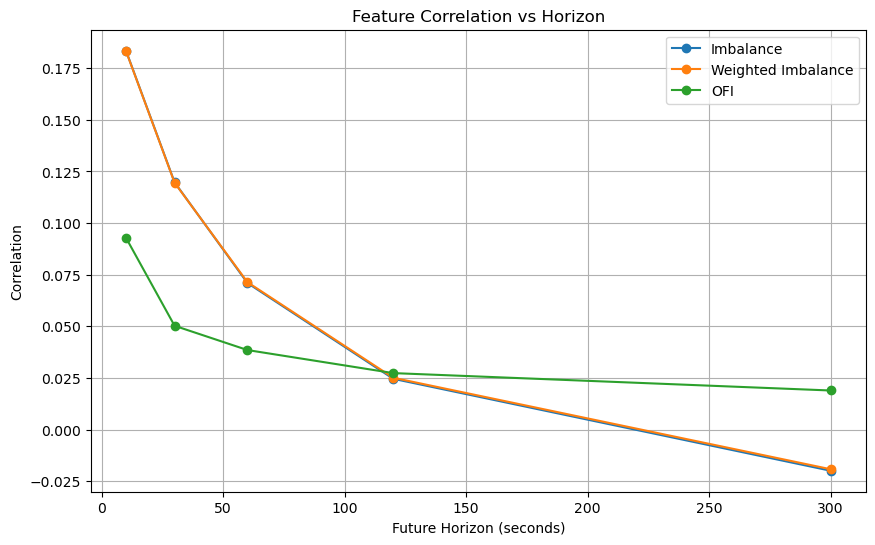

In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt

# ==========================
# Load Data
# ==========================

records = []

with open("orderbook.jsonl", "r") as f:

    for line in f:

        records.append(
            json.loads(line)
        )

print("Rows:", len(records))

# ==========================
# Feature Functions
# ==========================

def imbalance(snapshot, levels=5):

    bid_volume = sum(
        x[1]
        for x in snapshot["bids"][:levels]
    )

    ask_volume = sum(
        x[1]
        for x in snapshot["asks"][:levels]
    )

    total = bid_volume + ask_volume

    if total == 0:
        return 0

    return (
        bid_volume - ask_volume
    ) / total


def weighted_imbalance(snapshot, levels=5):

    weighted_bid = 0
    weighted_ask = 0

    for i, bid in enumerate(
        snapshot["bids"][:levels],
        start=1
    ):

        weight = 1 / i

        weighted_bid += (
            bid[1] * weight
        )

    for i, ask in enumerate(
        snapshot["asks"][:levels],
        start=1
    ):

        weight = 1 / i

        weighted_ask += (
            ask[1] * weight
        )

    total = (
        weighted_bid
        + weighted_ask
    )

    if total == 0:
        return 0

    return (
        weighted_bid
        - weighted_ask
    ) / total


# ==========================
# Build Features
# ==========================

for i, r in enumerate(records):

    r["imbalance"] = imbalance(
        r,
        levels=5
    )

    r["weighted_imbalance"] = (
        weighted_imbalance(
            r,
            levels=5
        )
    )

# ==========================
# OFI
# ==========================

records[0]["ofi"] = 0

for i in range(1, len(records)):

    prev_bid = records[i-1]["bids"][0][1]
    prev_ask = records[i-1]["asks"][0][1]

    curr_bid = records[i]["bids"][0][1]
    curr_ask = records[i]["asks"][0][1]

    bid_delta = (
        curr_bid - prev_bid
    )

    ask_delta = (
        curr_ask - prev_ask
    )

    records[i]["ofi"] = (
        bid_delta - ask_delta
    )

# ==========================
# Correlation Analysis
# ==========================

horizons = [
    10,
    30,
    60,
    120,
    300
]

imbalance_corrs = []
weighted_corrs = []
ofi_corrs = []

for horizon in horizons:

    future_returns = []

    imbalance_values = []
    weighted_values = []
    ofi_values = []

    for i in range(
        len(records) - horizon
    ):

        current_mid = (
            records[i]["mid_price"]
        )

        future_mid = (
            records[i + horizon]["mid_price"]
        )

        future_return = (
            future_mid
            - current_mid
        ) / current_mid

        future_returns.append(
            future_return
        )

        imbalance_values.append(
            records[i]["imbalance"]
        )

        weighted_values.append(
            records[i][
                "weighted_imbalance"
            ]
        )

        ofi_values.append(
            records[i]["ofi"]
        )

    imbalance_corr = (
        np.corrcoef(
            imbalance_values,
            future_returns
        )[0,1]
    )

    weighted_corr = (
        np.corrcoef(
            weighted_values,
            future_returns
        )[0,1]
    )

    ofi_corr = (
        np.corrcoef(
            ofi_values,
            future_returns
        )[0,1]
    )

    imbalance_corrs.append(
        imbalance_corr
    )

    weighted_corrs.append(
        weighted_corr
    )

    ofi_corrs.append(
        ofi_corr
    )

    print(
        f"Horizon {horizon:>3}s"
        f" | Imb={imbalance_corr:.4f}"
        f" | WImb={weighted_corr:.4f}"
        f" | OFI={ofi_corr:.4f}"
    )

# ==========================
# Plot
# ==========================

plt.figure(figsize=(10,6))

plt.plot(
    horizons,
    imbalance_corrs,
    marker="o",
    label="Imbalance"
)

plt.plot(
    horizons,
    weighted_corrs,
    marker="o",
    label="Weighted Imbalance"
)

plt.plot(
    horizons,
    ofi_corrs,
    marker="o",
    label="OFI"
)

plt.xlabel(
    "Future Horizon (seconds)"
)

plt.ylabel(
    "Correlation"
)

plt.title(
    "Feature Correlation vs Horizon"
)

plt.grid(True)

plt.legend()

plt.show()

In [2]:
import numpy as np

horizon = 10

trade_returns = []

for i in range(len(records) - horizon):

    imbalance = records[i]["imbalance"]

    if imbalance > 0.8:

        entry_price = records[i]["mid_price"]

        exit_price = records[
            i + horizon
        ]["mid_price"]

        trade_return = (
            exit_price
            -
            entry_price
        ) / entry_price

        trade_returns.append(
            trade_return
        )

print(
    "Trades:",
    len(trade_returns)
)

print(
    "Average Return:",
    np.mean(trade_returns)
)

print(
    "Win Rate:",
    np.mean(
        np.array(trade_returns) > 0
    )
)

Trades: 4892
Average Return: 8.306778419363861e-05
Win Rate: 0.60670482420278


In [3]:
import numpy as np

horizon = 10

trade_returns = []

for i in range(len(records) - horizon):

    imbalance = records[i]["imbalance"]

    if imbalance < -0.8:

        entry_price = records[i]["mid_price"]

        exit_price = records[
            i + horizon
        ]["mid_price"]

        trade_return = (
            entry_price
            -
            exit_price
        ) / entry_price

        trade_returns.append(
            trade_return
        )

print(
    "Trades:",
    len(trade_returns)
)

print(
    "Average Return:",
    np.mean(trade_returns)
)

print(
    "Win Rate:",
    np.mean(
        np.array(trade_returns) > 0
    )
)

Trades: 3888
Average Return: 7.662480710236478e-05
Win Rate: 0.5974794238683128


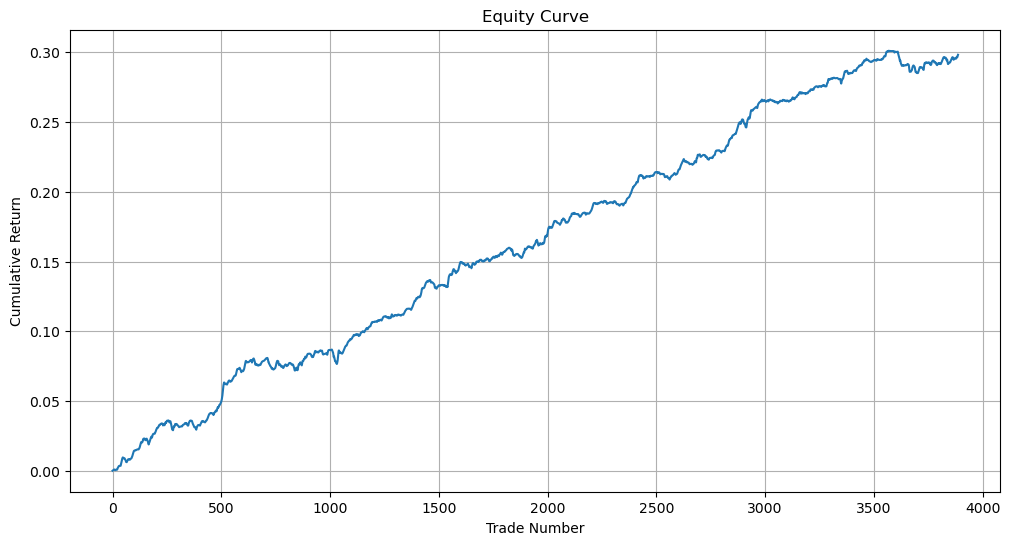

In [4]:
import numpy as np
import matplotlib.pyplot as plt

equity = np.cumsum(trade_returns)

plt.figure(figsize=(12,6))

plt.plot(equity)

plt.title("Equity Curve")

plt.xlabel("Trade Number")

plt.ylabel("Cumulative Return")

plt.grid(True)

plt.show()

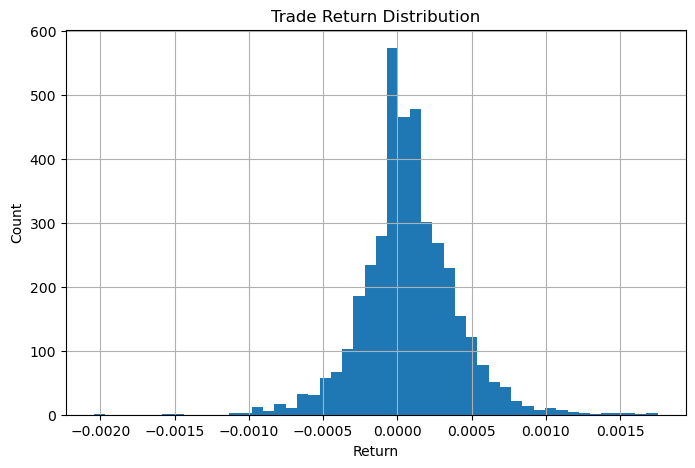

In [5]:
plt.figure(figsize=(8,5))

plt.hist(
    trade_returns,
    bins=50
)

plt.title("Trade Return Distribution")

plt.xlabel("Return")

plt.ylabel("Count")

plt.grid(True)

plt.show()

In [6]:
import numpy as np

returns = np.array(trade_returns)

sharpe = (
    returns.mean()
    /
    returns.std()
)

print("Sharpe Ratio =", sharpe)

Sharpe Ratio = 0.24210913933798092


In [7]:
import numpy as np
import pandas as pd

horizon = 10

results_table = []

thresholds = np.arange(0.50, 1.00, 0.05)

for th in thresholds:

    trade_returns = []

    for i in range(len(records) - horizon):

        imbalance = records[i]["imbalance"]

        if imbalance > th:

            entry = records[i]["mid_price"]
            exit = records[i+horizon]["mid_price"]

            ret = (exit-entry)/entry

            trade_returns.append(ret)

    if len(trade_returns) == 0:
        continue

    trade_returns = np.array(trade_returns)

    win_rate = np.mean(trade_returns > 0)

    avg_return = np.mean(trade_returns)

    sharpe = avg_return / np.std(trade_returns)

    results_table.append({

        "Threshold": th,

        "Trades": len(trade_returns),

        "WinRate": win_rate,

        "AverageReturn": avg_return,

        "Sharpe": sharpe

    })

df = pd.DataFrame(results_table)

print(df)

   Threshold  Trades   WinRate  AverageReturn    Sharpe
0       0.50    6935  0.579236       0.000066  0.208893
1       0.55    6628  0.582076       0.000068  0.213463
2       0.60    6328  0.585809       0.000070  0.218967
3       0.65    6006  0.591409       0.000073  0.228526
4       0.70    5661  0.594418       0.000076  0.235368
5       0.75    5284  0.600303       0.000080  0.248913
6       0.80    4892  0.606705       0.000083  0.257103
7       0.85    4310  0.605800       0.000085  0.260550
8       0.90    3564  0.613636       0.000092  0.274192
9       0.95    2381  0.628307       0.000103  0.302131


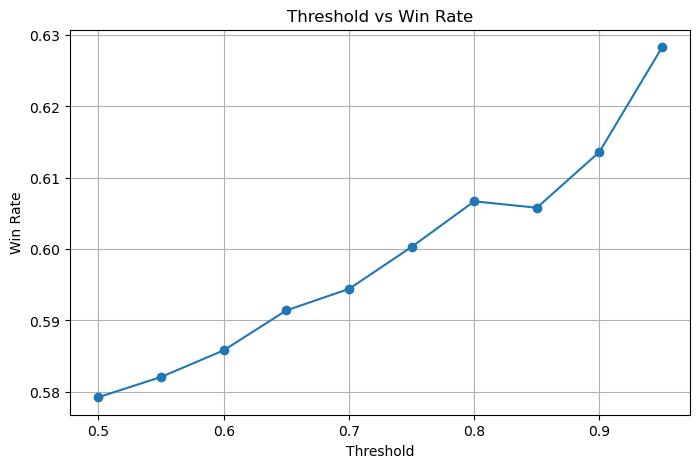

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(
    df["Threshold"],
    df["WinRate"],
    marker="o"
)

plt.grid(True)

plt.xlabel("Threshold")

plt.ylabel("Win Rate")

plt.title("Threshold vs Win Rate")

plt.show()

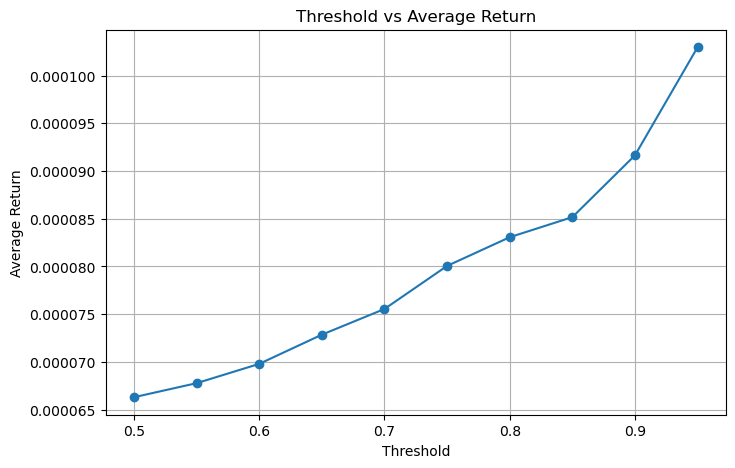

In [9]:
plt.figure(figsize=(8,5))

plt.plot(
    df["Threshold"],
    df["AverageReturn"],
    marker="o"
)

plt.grid(True)

plt.xlabel("Threshold")

plt.ylabel("Average Return")

plt.title("Threshold vs Average Return")

plt.show()

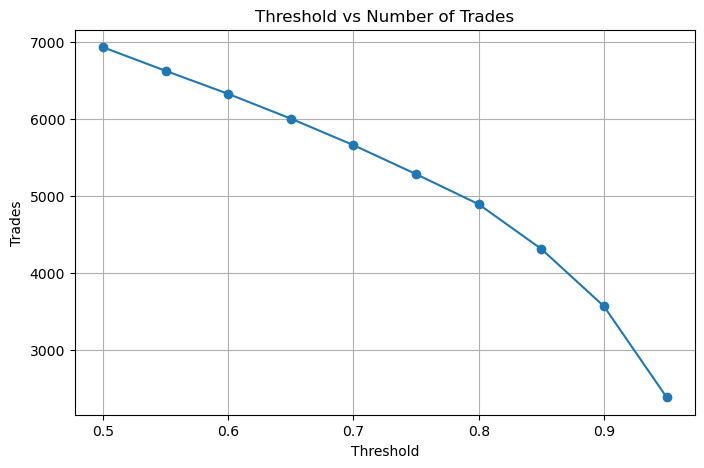

In [10]:
plt.figure(figsize=(8,5))

plt.plot(
    df["Threshold"],
    df["Trades"],
    marker="o"
)

plt.grid(True)

plt.xlabel("Threshold")

plt.ylabel("Trades")

plt.title("Threshold vs Number of Trades")

plt.show()

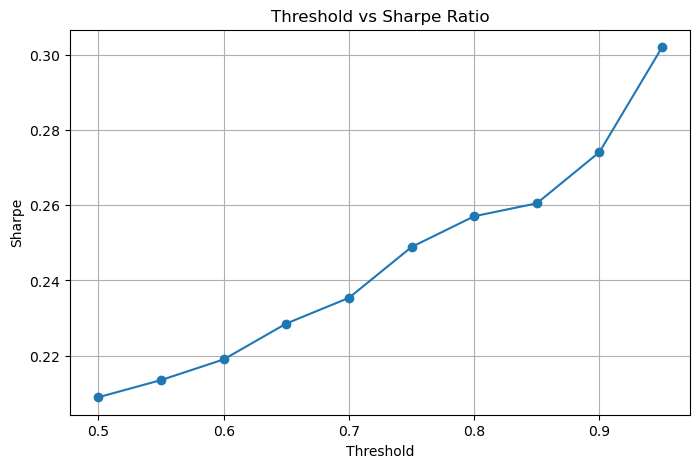

In [11]:
plt.figure(figsize=(8,5))

plt.plot(
    df["Threshold"],
    df["Sharpe"],
    marker="o"
)

plt.grid(True)

plt.xlabel("Threshold")

plt.ylabel("Sharpe")

plt.title("Threshold vs Sharpe Ratio")

plt.show()

In [12]:
import numpy as np

spreads = []

for row in records:
    spreads.append(row["spread"])

spreads = np.array(spreads)

print("Min :", spreads.min())
print("Max :", spreads.max())
print("Mean:", spreads.mean())
print("Std :", spreads.std())

print()

print("Percentiles")

for p in [50,75,90,95,99]:

    print(
        p,
        np.percentile(spreads,p)
    )

Min : 0.00999999999476131
Max : 14.5
Mean: 0.01385055555649645
Std : 0.17523153223262006

Percentiles
50 0.010000000002037268
75 0.010000000002037268
90 0.010000000002037268
95 0.010000000002037268
99 0.010000000002037268


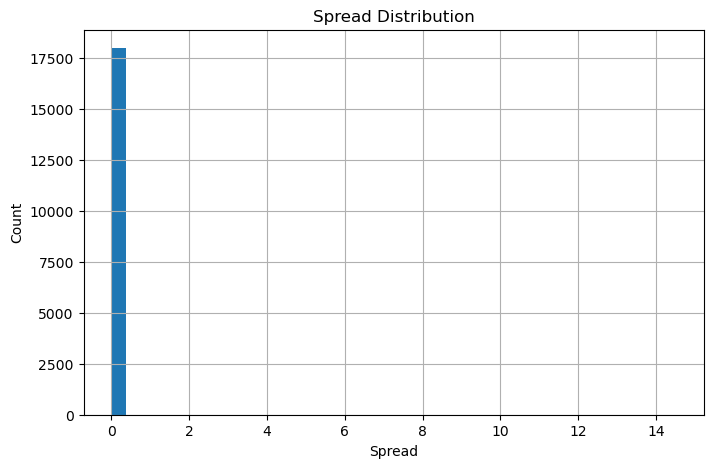

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(
    spreads,
    bins=40
)

plt.title("Spread Distribution")

plt.xlabel("Spread")

plt.ylabel("Count")

plt.grid(True)

plt.show()

### Feature Delta Imbalance

In [15]:
delta_imbalance = []

for i in range(1, len(records)):

    current = records[i]["imbalance_20"]

    previous = records[i-1]["imbalance_20"]

    delta = current - previous

    delta_imbalance.append(delta)

In [17]:
import numpy as np

delta = np.array(delta_imbalance)

print("Min :", delta.min())
print("Max :", delta.max())
print("Mean:", delta.mean())
print("Std :", delta.std())

Min : -1.9830492467640874
Max : 1.9833054248683784
Mean: -9.408031560469263e-05
Std : 0.5935915721804899


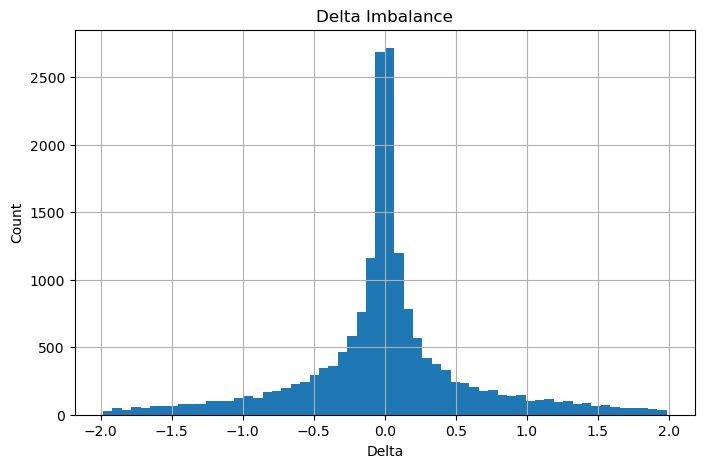

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(delta_imbalance,bins=60)

plt.grid(True)

plt.title("Delta Imbalance")

plt.xlabel("Delta")

plt.ylabel("Count")

plt.show()

In [28]:
import json

records = []

with open("orderbook.jsonl", "r", encoding="utf-8") as f:
    for line in f:
        records.append(json.loads(line))

results = []

LOOKAHEAD = 10

for i in range(len(records) - LOOKAHEAD):

    current_mid = records[i]["mid_price"]
    future_mid = records[i + LOOKAHEAD]["mid_price"]

    future_return = (
        (future_mid - current_mid)
        / current_mid
    )

    results.append({
        "timestamp": records[i]["timestamp"],
        "imbalance": records[i]["imbalance_20"],
        "mid_price": current_mid,
        "future_mid_price": future_mid,
        "future_return_10s": future_return
    })

print("Rows:", len(results))
print(results[:5])

Rows: 17990
[{'timestamp': '2026-06-08T04:57:34.085139', 'imbalance': 0.8198355455528187, 'mid_price': 62827.994999999995, 'future_mid_price': 62808.244999999995, 'future_return_10s': -0.000314350314696498}, {'timestamp': '2026-06-08T04:57:35.375783', 'imbalance': 0.8232104357673294, 'mid_price': 62827.994999999995, 'future_mid_price': 62808.244999999995, 'future_return_10s': -0.000314350314696498}, {'timestamp': '2026-06-08T04:57:36.668768', 'imbalance': 0.8195375591699233, 'mid_price': 62827.994999999995, 'future_mid_price': 62808.244999999995, 'future_return_10s': -0.000314350314696498}, {'timestamp': '2026-06-08T04:57:37.952183', 'imbalance': 0.8093771854098516, 'mid_price': 62827.994999999995, 'future_mid_price': 62808.005000000005, 'future_return_10s': -0.00031817026788759833}, {'timestamp': '2026-06-08T04:57:39.242639', 'imbalance': 0.8406008812135908, 'mid_price': 62827.994999999995, 'future_mid_price': 62806.005000000005, 'future_return_10s': -0.0003500032111480032}]


In [29]:
future_returns = []
delta_values = []

horizon = 10

for i in range(1, len(results)-horizon):

    delta = (
        results[i]["imbalance"]
        -
        results[i-1]["imbalance"]
    )

    future_return = results[i]["future_return_10s"]

    delta_values.append(delta)

    future_returns.append(future_return)

corr = np.corrcoef(
    delta_values,
    future_returns
)[0,1]

print(corr)

0.10063603886782108


In [30]:
label = 1 if future_return > 0 else 0

In [31]:
label

0

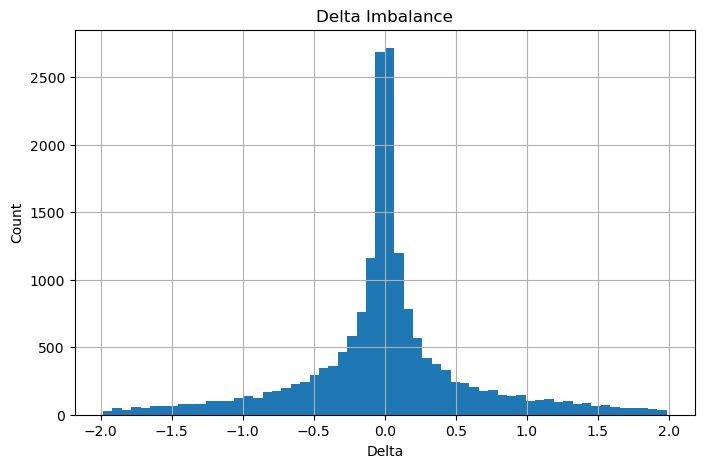

In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(delta_imbalance,bins=60)

plt.grid(True)

plt.title("Delta Imbalance")

plt.xlabel("Delta")

plt.ylabel("Count")

plt.show()

In [33]:
future_returns = []
delta_values = []

horizon = 20

for i in range(1, len(results)-horizon):

    delta = (
        results[i]["imbalance"]
        -
        results[i-1]["imbalance"]
    )

    future_return = results[i]["future_return_10s"]

    delta_values.append(delta)

    future_returns.append(future_return)

corr = np.corrcoef(
    delta_values,
    future_returns
)[0,1]

print(corr)

0.10058300902638276


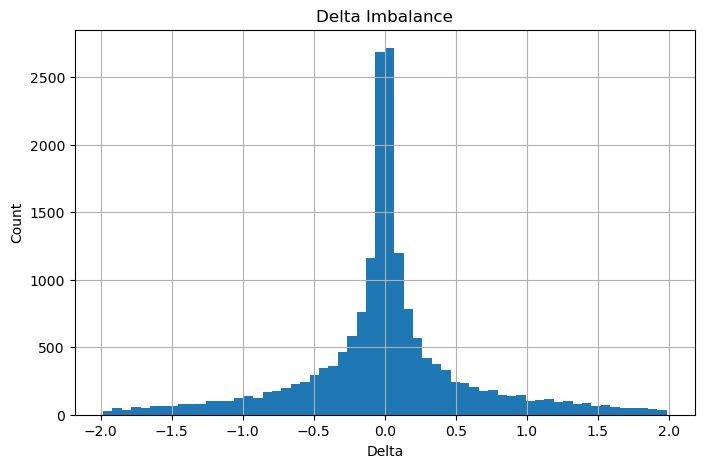

In [34]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(delta_imbalance,bins=60)

plt.grid(True)

plt.title("Delta Imbalance")

plt.xlabel("Delta")

plt.ylabel("Count")

plt.show()

In [35]:
future_returns = []
delta_values = []

horizon = 30

for i in range(1, len(results)-horizon):

    delta = (
        results[i]["imbalance"]
        -
        results[i-1]["imbalance"]
    )

    future_return = results[i]["future_return_10s"]

    delta_values.append(delta)

    future_returns.append(future_return)

corr = np.corrcoef(
    delta_values,
    future_returns
)[0,1]

print(corr)

0.10061661228000263


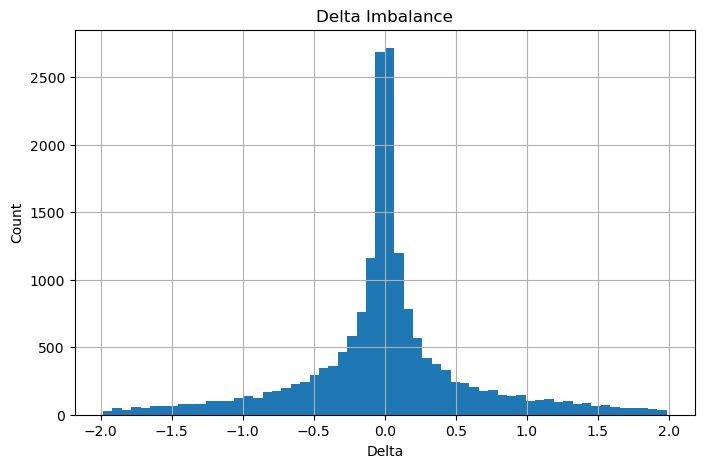

In [36]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(delta_imbalance,bins=60)

plt.grid(True)

plt.title("Delta Imbalance")

plt.xlabel("Delta")

plt.ylabel("Count")

plt.show()

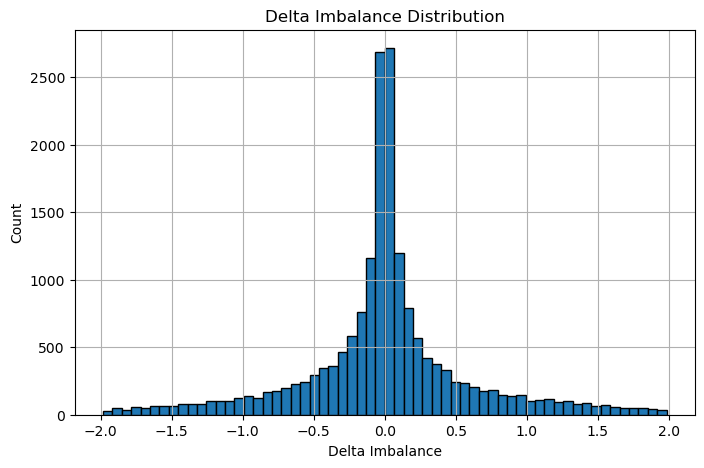

Correlation
Horizon  10s -> Corr = 0.1006
Horizon  30s -> Corr = 0.0555
Horizon  60s -> Corr = 0.0411
Horizon 120s -> Corr = 0.0301
Horizon 300s -> Corr = 0.0204


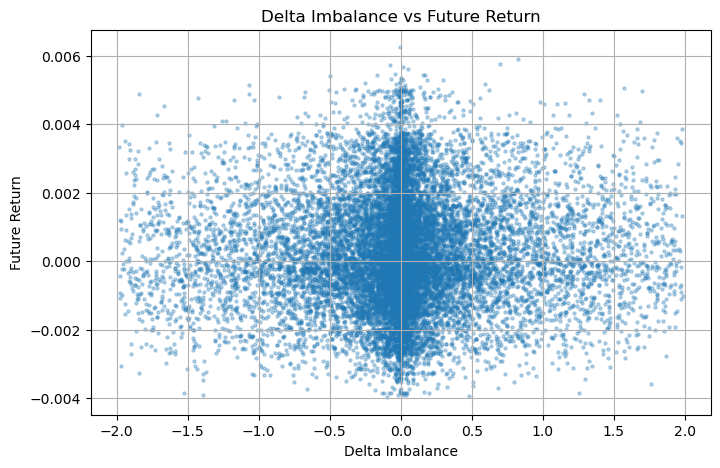


UP Probability
[-1.0,-0.8] Count=  419 UP=35.80%
[-0.8,-0.6] Count=  601 UP=45.09%
[-0.6,-0.4] Count=  887 UP=41.71%
[-0.4,-0.2] Count= 1413 UP=43.52%
[-0.2,-0.0] Count= 4578 UP=47.36%
[-0.0, 0.2] Count= 4754 UP=50.21%
[ 0.2, 0.4] Count= 1374 UP=52.40%
[ 0.4, 0.6] Count=  800 UP=52.62%
[ 0.6, 0.8] Count=  560 UP=58.39%
[ 0.8, 1.0] Count=  433 UP=54.73%

Average Future Return
[-1.0,-0.8] Count=  419 AvgReturn=-0.00007486
[-0.8,-0.6] Count=  601 AvgReturn=-0.00001933
[-0.6,-0.4] Count=  887 AvgReturn=-0.00003205
[-0.4,-0.2] Count= 1413 AvgReturn=-0.00001544
[-0.2,-0.0] Count= 4578 AvgReturn=0.00000165
[-0.0, 0.2] Count= 4754 AvgReturn=0.00001910
[ 0.2, 0.4] Count= 1374 AvgReturn=0.00003120
[ 0.4, 0.6] Count=  800 AvgReturn=0.00002984
[ 0.6, 0.8] Count=  560 AvgReturn=0.00007401
[ 0.8, 1.0] Count=  433 AvgReturn=0.00005064


In [37]:
import numpy as np
import matplotlib.pyplot as plt

# ===========================
# Delta Imbalance
# ===========================

delta_imbalance = []

for i in range(len(results)):

    if i == 0:
        delta_imbalance.append(0)

    else:

        delta = (
            results[i]["imbalance"]
            -
            results[i-1]["imbalance"]
        )

        delta_imbalance.append(delta)

# ==========================================
# Histogram
# ==========================================

plt.figure(figsize=(8,5))

plt.hist(
    delta_imbalance,
    bins=60,
    edgecolor="black"
)

plt.title("Delta Imbalance Distribution")

plt.xlabel("Delta Imbalance")

plt.ylabel("Count")

plt.grid(True)

plt.show()

# ==========================================
# Correlation
# ==========================================

print("="*50)
print("Correlation")
print("="*50)

horizons = [10,30,60,120,300]

for horizon in horizons:

    x = []
    y = []

    for i in range(1, len(results)-horizon):

        delta = (
            results[i]["imbalance"]
            -
            results[i-1]["imbalance"]
        )

        future_return = (
            results[i+horizon]["mid_price"]
            -
            results[i]["mid_price"]
        ) / results[i]["mid_price"]

        x.append(delta)
        y.append(future_return)

    corr = np.corrcoef(x,y)[0,1]

    print(
        f"Horizon {horizon:>3}s -> Corr = {corr:.4f}"
    )

# ==========================================
# Scatter Plot
# ==========================================

plt.figure(figsize=(8,5))

plt.scatter(
    x,
    y,
    s=5,
    alpha=0.3
)

plt.title("Delta Imbalance vs Future Return")

plt.xlabel("Delta Imbalance")

plt.ylabel("Future Return")

plt.grid(True)

plt.show()

# ==========================================
# UP Probability
# ==========================================

print()
print("="*50)
print("UP Probability")
print("="*50)

bins = np.arange(-1.0,1.2,0.2)

for low, high in zip(bins[:-1], bins[1:]):

    labels=[]

    for i in range(1, len(results)-10):

        delta = (
            results[i]["imbalance"]
            -
            results[i-1]["imbalance"]
        )

        if low <= delta < high:

            future_return = (
                results[i+10]["mid_price"]
                -
                results[i]["mid_price"]
            ) / results[i]["mid_price"]

            labels.append(
                1 if future_return>0 else 0
            )

    if len(labels)==0:
        continue

    print(
        f"[{low:>4.1f},{high:>4.1f}]"
        f" Count={len(labels):5d}"
        f" UP={100*np.mean(labels):5.2f}%"
    )

# ==========================================
# Average Return
# ==========================================

print()
print("="*50)
print("Average Future Return")
print("="*50)

for low, high in zip(bins[:-1], bins[1:]):

    returns=[]

    for i in range(1, len(results)-10):

        delta = (
            results[i]["imbalance"]
            -
            results[i-1]["imbalance"]
        )

        if low <= delta < high:

            future_return = (
                results[i+10]["mid_price"]
                -
                results[i]["mid_price"]
            ) / results[i]["mid_price"]

            returns.append(future_return)

    if len(returns)==0:
        continue

    print(
        f"[{low:>4.1f},{high:>4.1f}]"
        f" Count={len(returns):5d}"
        f" AvgReturn={np.mean(returns):.8f}"
    )

In [ ]:
1